# 07 Simple Linear Regression

## Model 1: OLS with Campaign_Engagement_Score

Target: `Sales`  
Predictor: `Campaign_Engagement_Score`

This notebook:
- Loads the training split
- Fits a simple linear regression using `statsmodels` OLS
- Plots actual data with the fitted regression line
- Prints full model summary and key metrics


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')

In [4]:
train_path = Path('../data/processed/splits/ElectraHub_train.csv')
if not train_path.exists():
    raise FileNotFoundError(f'Training dataset not found: {train_path}')

train_df = pd.read_csv(train_path)
print(f'Loaded training set: {train_path.name}')
print(f'Shape: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')

Loaded training set: ElectraHub_train.csv
Shape: 2,400 rows x 16 columns


In [5]:
X = train_df[['Campaign_Engagement_Score']].copy()
y = train_df['Sales'].copy()

X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

y_pred = ols_model.predict(X_const)

rmse = mean_squared_error(y, y_pred) ** 0.5
mae = mean_absolute_error(y, y_pred)

intercept = ols_model.params['const']
coefficient = ols_model.params['Campaign_Engagement_Score']
p_value = ols_model.pvalues['Campaign_Engagement_Score']
r2 = ols_model.rsquared
f_stat = ols_model.fvalue

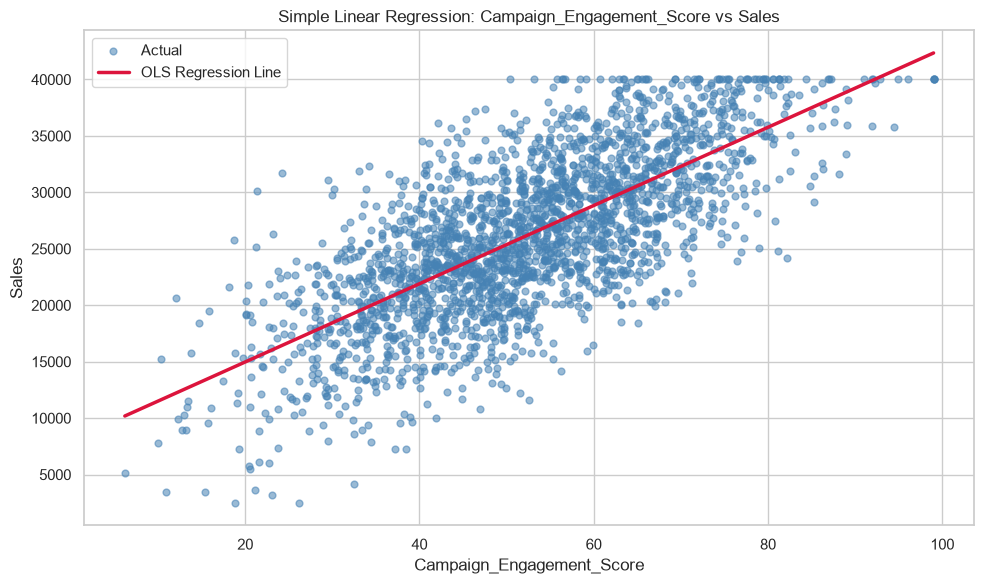

In [6]:
# Scatter plot of actual values with fitted regression line
plot_df = train_df[['Campaign_Engagement_Score', 'Sales']].copy().sort_values('Campaign_Engagement_Score')
plot_df['Predicted_Sales'] = ols_model.predict(sm.add_constant(plot_df[['Campaign_Engagement_Score']]))

plt.figure(figsize=(10, 6))
plt.scatter(
    train_df['Campaign_Engagement_Score'],
    train_df['Sales'],
    alpha=0.55,
    s=24,
    color='steelblue',
    label='Actual'
)
plt.plot(
    plot_df['Campaign_Engagement_Score'],
    plot_df['Predicted_Sales'],
    color='crimson',
    linewidth=2.5,
    label='OLS Regression Line'
)
plt.title('Simple Linear Regression: Campaign_Engagement_Score vs Sales')
plt.xlabel('Campaign_Engagement_Score')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
print('Full OLS Model Summary:')
print(ols_model.summary())

Full OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     2556.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:09:32   Log-Likelihood:                -23807.
No. Observations:                2400   AIC:                         4.762e+04
Df Residuals:                    2398   BIC:                         4.763e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [8]:
print('Key Model Outputs')
print(f'Intercept (const): {intercept:,.4f}')
print(f'Coefficient (Campaign_Engagement_Score): {coefficient:,.4f}')
print(f'P-value (Campaign_Engagement_Score): {p_value:.6g}')
print(f'R-squared: {r2:.6f}')
print(f'RMSE: {rmse:,.4f}')
print(f'MAE: {mae:,.4f}')
print(f'F-statistic: {f_stat:,.4f}')

Key Model Outputs
Intercept (const): 8,046.2919
Coefficient (Campaign_Engagement_Score): 346.4969
P-value (Campaign_Engagement_Score): 0
R-squared: 0.515939
RMSE: 4,916.9702
MAE: 3,931.3258
F-statistic: 2,555.9171


## Assumption Checks for Linear Regression

Diagnostics included:
- Residuals vs Fitted plot (linearity and constant variance check)
- Q-Q plot (normality of residuals)
- Durbin-Watson statistic (autocorrelation)
- Jarque-Bera test (normality)
- Breusch-Pagan test (heteroscedasticity)


In [9]:
from scipy.stats import jarque_bera
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot

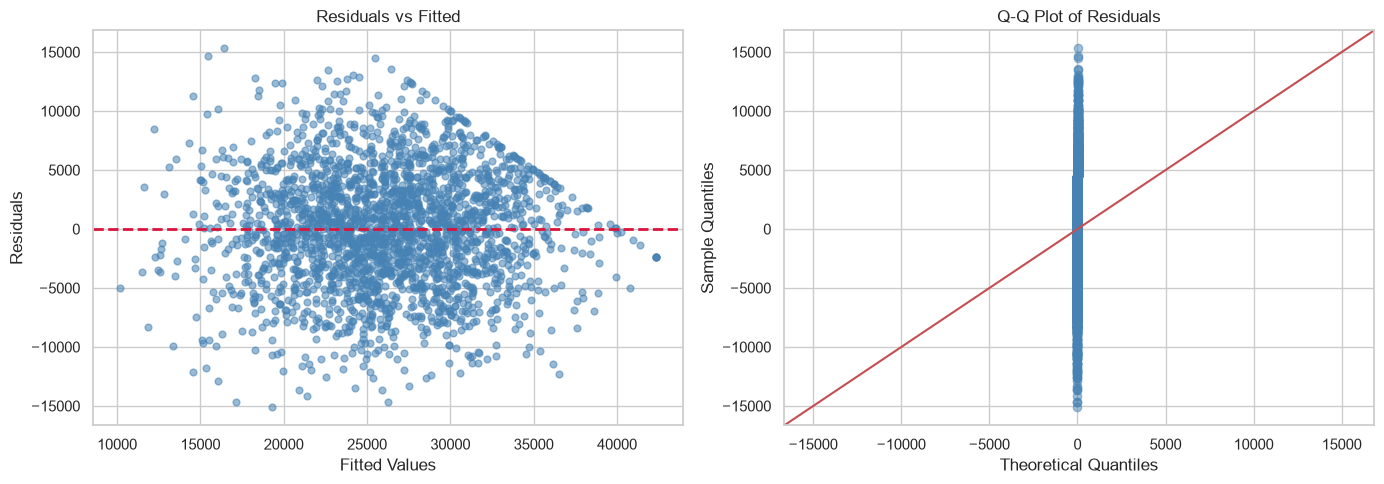

In [10]:
residuals = y - y_pred
fitted = y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.55, color='steelblue', s=24)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q Plot
qqplot(residuals, line='45', ax=axes[1], markerfacecolor='steelblue', markeredgecolor='steelblue', alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [11]:
# Statistical assumption tests

dw_stat = durbin_watson(residuals)
jb_stat, jb_p = jarque_bera(residuals)
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, X_const)

print('Durbin-Watson:', round(dw_stat, 4))
print('Jarque-Bera statistic:', round(jb_stat, 4), '| p-value:', f'{jb_p:.6g}')
print('Breusch-Pagan LM statistic:', round(bp_lm, 4), '| p-value:', f'{bp_lm_p:.6g}')
print('Breusch-Pagan F statistic :', round(bp_f, 4), '| p-value:', f'{bp_f_p:.6g}')

Durbin-Watson: 1.9801
Jarque-Bera statistic: 2.2137 | p-value: 0.330597
Breusch-Pagan LM statistic: 11.6863 | p-value: 0.000629618
Breusch-Pagan F statistic : 11.7337 | p-value: 0.000624112


In [12]:
print('Interpretation Notes:')

# Residual vs fitted interpretation
corr_abs = np.corrcoef(fitted, np.abs(residuals))[0, 1]
if abs(corr_abs) < 0.1:
    rvf_msg = 'Residual spread does not strongly change with fitted values, which is supportive of near-constant variance.'
elif corr_abs > 0:
    rvf_msg = 'Residual spread appears to increase as fitted values increase, suggesting possible heteroscedasticity.'
else:
    rvf_msg = 'Residual spread appears to decrease as fitted values increase; variance may not be fully constant.'
print(f'- Residual vs Fitted: {rvf_msg}')

# Q-Q / normality interpretation
if jb_p > 0.05:
    qq_msg = 'Residual normality is not rejected at 5%; Q-Q points should be reasonably close to the line.'
else:
    qq_msg = 'Residual normality is rejected at 5%; expect tail deviations in the Q-Q plot.'
print(f'- Q-Q + Jarque-Bera: {qq_msg}')

# Durbin-Watson interpretation
if 1.5 <= dw_stat <= 2.5:
    dw_msg = 'DW is near 2, indicating little evidence of autocorrelation in residuals.'
elif dw_stat < 1.5:
    dw_msg = 'DW is materially below 2, suggesting positive autocorrelation.'
else:
    dw_msg = 'DW is materially above 2, suggesting negative autocorrelation.'
print(f'- Durbin-Watson: {dw_msg}')

# Breusch-Pagan interpretation
if bp_lm_p > 0.05:
    bp_msg = 'Homoscedasticity is not rejected at 5%; variance looks reasonably constant.'
else:
    bp_msg = 'Homoscedasticity is rejected at 5%; heteroscedasticity is likely present.'
print(f'- Breusch-Pagan: {bp_msg}')

Interpretation Notes:
- Residual vs Fitted: Residual spread does not strongly change with fitted values, which is supportive of near-constant variance.
- Q-Q + Jarque-Bera: Residual normality is not rejected at 5%; Q-Q points should be reasonably close to the line.
- Durbin-Watson: DW is near 2, indicating little evidence of autocorrelation in residuals.
- Breusch-Pagan: Homoscedasticity is rejected at 5%; heteroscedasticity is likely present.


## Model 2: OLS with Advertising_Expenditure

Target: `Sales`  
Predictor: `Advertising_Expenditure`


In [13]:
X_adv = train_df[['Advertising_Expenditure']].copy()
y_adv = train_df['Sales'].copy()

X_adv_const = sm.add_constant(X_adv)
ols_model_adv = sm.OLS(y_adv, X_adv_const).fit()

y_adv_pred = ols_model_adv.predict(X_adv_const)

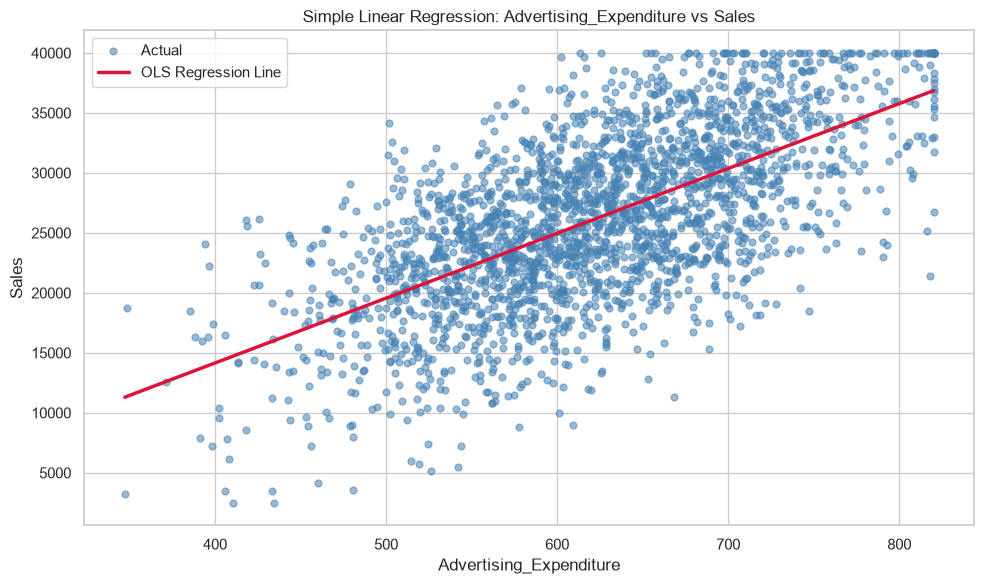

In [14]:
# Scatter of actual values with fitted regression line
plot_adv = train_df[['Advertising_Expenditure', 'Sales']].copy().sort_values('Advertising_Expenditure')
plot_adv['Predicted_Sales'] = ols_model_adv.predict(sm.add_constant(plot_adv[['Advertising_Expenditure']]))

plt.figure(figsize=(10, 6))
plt.scatter(
    train_df['Advertising_Expenditure'],
    train_df['Sales'],
    alpha=0.55,
    s=24,
    color='steelblue',
    label='Actual'
)
plt.plot(
    plot_adv['Advertising_Expenditure'],
    plot_adv['Predicted_Sales'],
    color='crimson',
    linewidth=2.5,
    label='OLS Regression Line'
)
plt.title('Simple Linear Regression: Advertising_Expenditure vs Sales')
plt.xlabel('Advertising_Expenditure')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
print('Full OLS Model Summary (Advertising_Expenditure -> Sales):')
print(ols_model_adv.summary())

Full OLS Model Summary (Advertising_Expenditure -> Sales):
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     1729.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          4.75e-285
Time:                        10:59:12   Log-Likelihood:                -24026.
No. Observations:                2400   AIC:                         4.806e+04
Df Residuals:                    2398   BIC:                         4.807e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

## Assumption Checks for Model 2 (Advertising_Expenditure)

Diagnostics included for the second simple linear model:
- Residuals vs Fitted
- Q-Q plot
- Durbin-Watson
- Jarque-Bera
- Breusch-Pagan


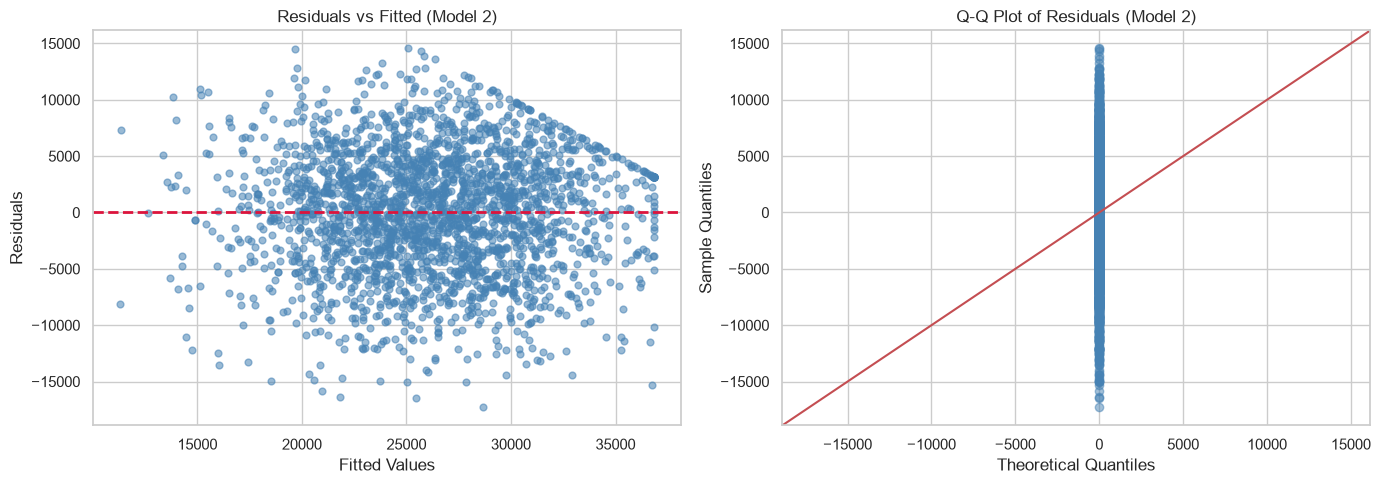

In [16]:
residuals_adv = y_adv - y_adv_pred
fitted_adv = y_adv_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_adv, residuals_adv, alpha=0.55, color='steelblue', s=24)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted (Model 2)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q plot
qqplot(residuals_adv, line='45', ax=axes[1], markerfacecolor='steelblue', markeredgecolor='steelblue', alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals (Model 2)')

plt.tight_layout()
plt.show()

In [17]:
dw_stat_adv = durbin_watson(residuals_adv)
jb_stat_adv, jb_p_adv = jarque_bera(residuals_adv)
bp_lm_adv, bp_lm_p_adv, bp_f_adv, bp_f_p_adv = het_breuschpagan(residuals_adv, X_adv_const)

print('Durbin-Watson (Model 2):', round(dw_stat_adv, 4))
print('Jarque-Bera statistic (Model 2):', round(jb_stat_adv, 4), '| p-value:', f'{jb_p_adv:.6g}')
print('Breusch-Pagan LM statistic (Model 2):', round(bp_lm_adv, 4), '| p-value:', f'{bp_lm_p_adv:.6g}')
print('Breusch-Pagan F statistic  (Model 2):', round(bp_f_adv, 4), '| p-value:', f'{bp_f_p_adv:.6g}')

Durbin-Watson (Model 2): 2.02
Jarque-Bera statistic (Model 2): 21.7634 | p-value: 1.87994e-05
Breusch-Pagan LM statistic (Model 2): 3.2342 | p-value: 0.0721159
Breusch-Pagan F statistic  (Model 2): 3.2359 | p-value: 0.0721683


In [18]:
print('Interpretation Notes (Model 2):')

corr_abs_adv = np.corrcoef(fitted_adv, np.abs(residuals_adv))[0, 1]
if abs(corr_abs_adv) < 0.1:
    rvf_msg_adv = 'Residual spread does not strongly change with fitted values, supportive of near-constant variance.'
elif corr_abs_adv > 0:
    rvf_msg_adv = 'Residual spread tends to increase with fitted values, suggesting possible heteroscedasticity.'
else:
    rvf_msg_adv = 'Residual spread tends to decrease with fitted values; variance may not be fully constant.'
print(f'- Residual vs Fitted: {rvf_msg_adv}')

if jb_p_adv > 0.05:
    qq_msg_adv = 'Residual normality is not rejected at 5%; Q-Q points should be reasonably close to the line.'
else:
    qq_msg_adv = 'Residual normality is rejected at 5%; Q-Q plot likely shows notable tail departures.'
print(f'- Q-Q + Jarque-Bera: {qq_msg_adv}')

if 1.5 <= dw_stat_adv <= 2.5:
    dw_msg_adv = 'DW is near 2, indicating little evidence of autocorrelation.'
elif dw_stat_adv < 1.5:
    dw_msg_adv = 'DW is materially below 2, suggesting positive autocorrelation.'
else:
    dw_msg_adv = 'DW is materially above 2, suggesting negative autocorrelation.'
print(f'- Durbin-Watson: {dw_msg_adv}')

if bp_lm_p_adv > 0.05:
    bp_msg_adv = 'Homoscedasticity is not rejected at 5%; variance appears reasonably constant.'
else:
    bp_msg_adv = 'Homoscedasticity is rejected at 5%; heteroscedasticity is likely present.'
print(f'- Breusch-Pagan: {bp_msg_adv}')

Interpretation Notes (Model 2):
- Residual vs Fitted: Residual spread does not strongly change with fitted values, supportive of near-constant variance.
- Q-Q + Jarque-Bera: Residual normality is rejected at 5%; Q-Q plot likely shows notable tail departures.
- Durbin-Watson: DW is near 2, indicating little evidence of autocorrelation.
- Breusch-Pagan: Homoscedasticity is not rejected at 5%; variance appears reasonably constant.


## Model 3: OLS with Avg_Customer_Rating

Target: `Sales`  
Predictor: `Avg_Customer_Rating`


In [19]:
X_rating = train_df[['Avg_Customer_Rating']].copy()
y_rating = train_df['Sales'].copy()

X_rating_const = sm.add_constant(X_rating)
ols_model_rating = sm.OLS(y_rating, X_rating_const).fit()

y_rating_pred = ols_model_rating.predict(X_rating_const)

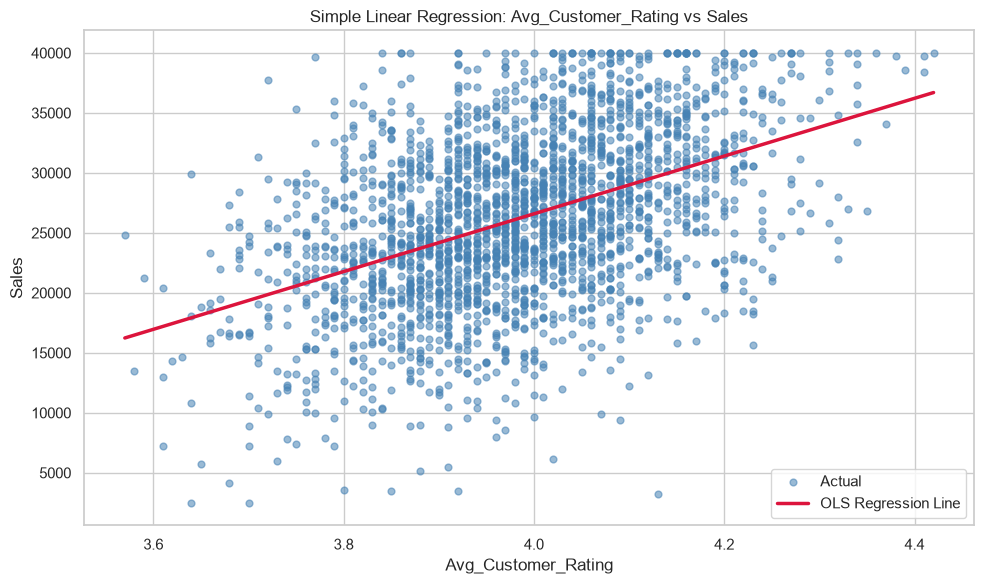

In [20]:
# Scatter of actual values with fitted regression line
plot_rating = train_df[['Avg_Customer_Rating', 'Sales']].copy().sort_values('Avg_Customer_Rating')
plot_rating['Predicted_Sales'] = ols_model_rating.predict(sm.add_constant(plot_rating[['Avg_Customer_Rating']]))

plt.figure(figsize=(10, 6))
plt.scatter(
    train_df['Avg_Customer_Rating'],
    train_df['Sales'],
    alpha=0.55,
    s=24,
    color='steelblue',
    label='Actual'
)
plt.plot(
    plot_rating['Avg_Customer_Rating'],
    plot_rating['Predicted_Sales'],
    color='crimson',
    linewidth=2.5,
    label='OLS Regression Line'
)
plt.title('Simple Linear Regression: Avg_Customer_Rating vs Sales')
plt.xlabel('Avg_Customer_Rating')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
print('Full OLS Model Summary (Avg_Customer_Rating -> Sales):')
print(ols_model_rating.summary())

Full OLS Model Summary (Avg_Customer_Rating -> Sales):
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     615.4
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          4.02e-121
Time:                        11:18:18   Log-Likelihood:                -24403.
No. Observations:                2400   AIC:                         4.881e+04
Df Residuals:                    2398   BIC:                         4.882e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

## Assumption Checks for Model 3 (Avg_Customer_Rating)

Diagnostics included for the third simple linear model:
- Residuals vs Fitted
- Q-Q plot
- Durbin-Watson
- Jarque-Bera
- Breusch-Pagan


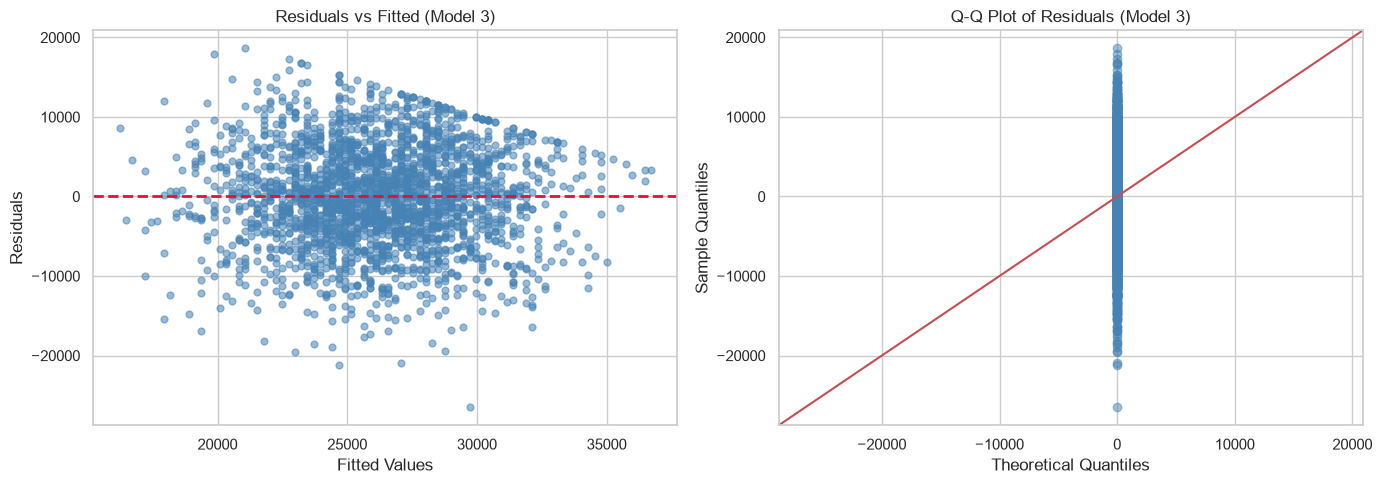

In [22]:
residuals_rating = y_rating - y_rating_pred
fitted_rating = y_rating_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_rating, residuals_rating, alpha=0.55, color='steelblue', s=24)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted (Model 3)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q plot
qqplot(residuals_rating, line='45', ax=axes[1], markerfacecolor='steelblue', markeredgecolor='steelblue', alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals (Model 3)')

plt.tight_layout()
plt.show()

In [23]:
dw_stat_rating = durbin_watson(residuals_rating)
jb_stat_rating, jb_p_rating = jarque_bera(residuals_rating)
bp_lm_rating, bp_lm_p_rating, bp_f_rating, bp_f_p_rating = het_breuschpagan(residuals_rating, X_rating_const)

print('Durbin-Watson (Model 3):', round(dw_stat_rating, 4))
print('Jarque-Bera statistic (Model 3):', round(jb_stat_rating, 4), '| p-value:', f'{jb_p_rating:.6g}')
print('Breusch-Pagan LM statistic (Model 3):', round(bp_lm_rating, 4), '| p-value:', f'{bp_lm_p_rating:.6g}')
print('Breusch-Pagan F statistic  (Model 3):', round(bp_f_rating, 4), '| p-value:', f'{bp_f_p_rating:.6g}')

Durbin-Watson (Model 3): 1.961
Jarque-Bera statistic (Model 3): 9.731 | p-value: 0.00770794
Breusch-Pagan LM statistic (Model 3): 2.1505 | p-value: 0.142521
Breusch-Pagan F statistic  (Model 3): 2.1507 | p-value: 0.142639


In [24]:
print('Interpretation Notes (Model 3):')

corr_abs_rating = np.corrcoef(fitted_rating, np.abs(residuals_rating))[0, 1]
if abs(corr_abs_rating) < 0.1:
    rvf_msg_rating = 'Residual spread does not strongly change with fitted values, supportive of near-constant variance.'
elif corr_abs_rating > 0:
    rvf_msg_rating = 'Residual spread tends to increase with fitted values, suggesting possible heteroscedasticity.'
else:
    rvf_msg_rating = 'Residual spread tends to decrease with fitted values; variance may not be fully constant.'
print(f'- Residual vs Fitted: {rvf_msg_rating}')

if jb_p_rating > 0.05:
    qq_msg_rating = 'Residual normality is not rejected at 5%; Q-Q points should be reasonably close to the line.'
else:
    qq_msg_rating = 'Residual normality is rejected at 5%; Q-Q plot likely shows notable tail departures.'
print(f'- Q-Q + Jarque-Bera: {qq_msg_rating}')

if 1.5 <= dw_stat_rating <= 2.5:
    dw_msg_rating = 'DW is near 2, indicating little evidence of autocorrelation.'
elif dw_stat_rating < 1.5:
    dw_msg_rating = 'DW is materially below 2, suggesting positive autocorrelation.'
else:
    dw_msg_rating = 'DW is materially above 2, suggesting negative autocorrelation.'
print(f'- Durbin-Watson: {dw_msg_rating}')

if bp_lm_p_rating > 0.05:
    bp_msg_rating = 'Homoscedasticity is not rejected at 5%; variance appears reasonably constant.'
else:
    bp_msg_rating = 'Homoscedasticity is rejected at 5%; heteroscedasticity is likely present.'
print(f'- Breusch-Pagan: {bp_msg_rating}')

Interpretation Notes (Model 3):
- Residual vs Fitted: Residual spread does not strongly change with fitted values, supportive of near-constant variance.
- Q-Q + Jarque-Bera: Residual normality is rejected at 5%; Q-Q plot likely shows notable tail departures.
- Durbin-Watson: DW is near 2, indicating little evidence of autocorrelation.
- Breusch-Pagan: Homoscedasticity is not rejected at 5%; variance appears reasonably constant.


## Test-Set Comparison: All Simple LR Models

This table compares all three simple linear regression models on the held-out test set,
with a naive baseline row at the top for reference.


In [25]:
from sklearn.metrics import r2_score
# Load held-out test set
test_path = Path('../data/processed/splits/ElectraHub_test.csv')
if not test_path.exists():
    raise FileNotFoundError(f'Test dataset not found: {test_path}')

test_df = pd.read_csv(test_path)
y_test = test_df['Sales']

rows = []

# Naive baseline: predict train mean for every test row
baseline_pred = np.full(shape=len(y_test), fill_value=train_df['Sales'].mean())
rows.append({
    'Predictor': 'Naive baseline (train mean)',
    'Coefficient': np.nan,
    'R² (test)': r2_score(y_test, baseline_pred),
    'RMSE (test)': mean_squared_error(y_test, baseline_pred) ** 0.5,
    'MAE (test)': mean_absolute_error(y_test, baseline_pred)
})

# Helper to evaluate one simple OLS model
for predictor in ['Campaign_Engagement_Score', 'Advertising_Expenditure', 'Avg_Customer_Rating']:
    X_train_one = sm.add_constant(train_df[[predictor]])
    model_one = sm.OLS(train_df['Sales'], X_train_one).fit()

    X_test_one = sm.add_constant(test_df[[predictor]])
    y_test_pred = model_one.predict(X_test_one)

    rows.append({
        'Predictor': predictor,
        'Coefficient': model_one.params[predictor],
        'R² (test)': r2_score(y_test, y_test_pred),
        'RMSE (test)': mean_squared_error(y_test, y_test_pred) ** 0.5,
        'MAE (test)': mean_absolute_error(y_test, y_test_pred)
    })

comparison_df = pd.DataFrame(rows)
comparison_df['Coefficient'] = comparison_df['Coefficient'].round(4)
comparison_df['R² (test)'] = comparison_df['R² (test)'].round(4)
comparison_df['RMSE (test)'] = comparison_df['RMSE (test)'].round(2)
comparison_df['MAE (test)'] = comparison_df['MAE (test)'].round(2)

display(comparison_df)


,Predictor,Coefficient,R² (test),RMSE (test),MAE (test)
0,Naive baseline (train mean),NaN,-0.0019,7053.06,5707.65
1,Campaign_Engagement_Score,346.4969,0.5439,4758.87,3768.53
2,Advertising_Expenditure,54.0536,0.4565,5194.56,4192.74
3,Avg_Customer_Rating,24071.9707,0.1552,6476.28,5208.20
